In [1]:
from tensorflow import keras
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Convolutional Neural Networks
## Convolution

In [10]:
from sklearn.datasets import load_sample_image
# Load sample images
china = load_sample_image("china.jpg") / 255
flower = load_sample_image("flower.jpg") / 255
images = np.array([china, flower])

In [11]:
from tensorflow import keras
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

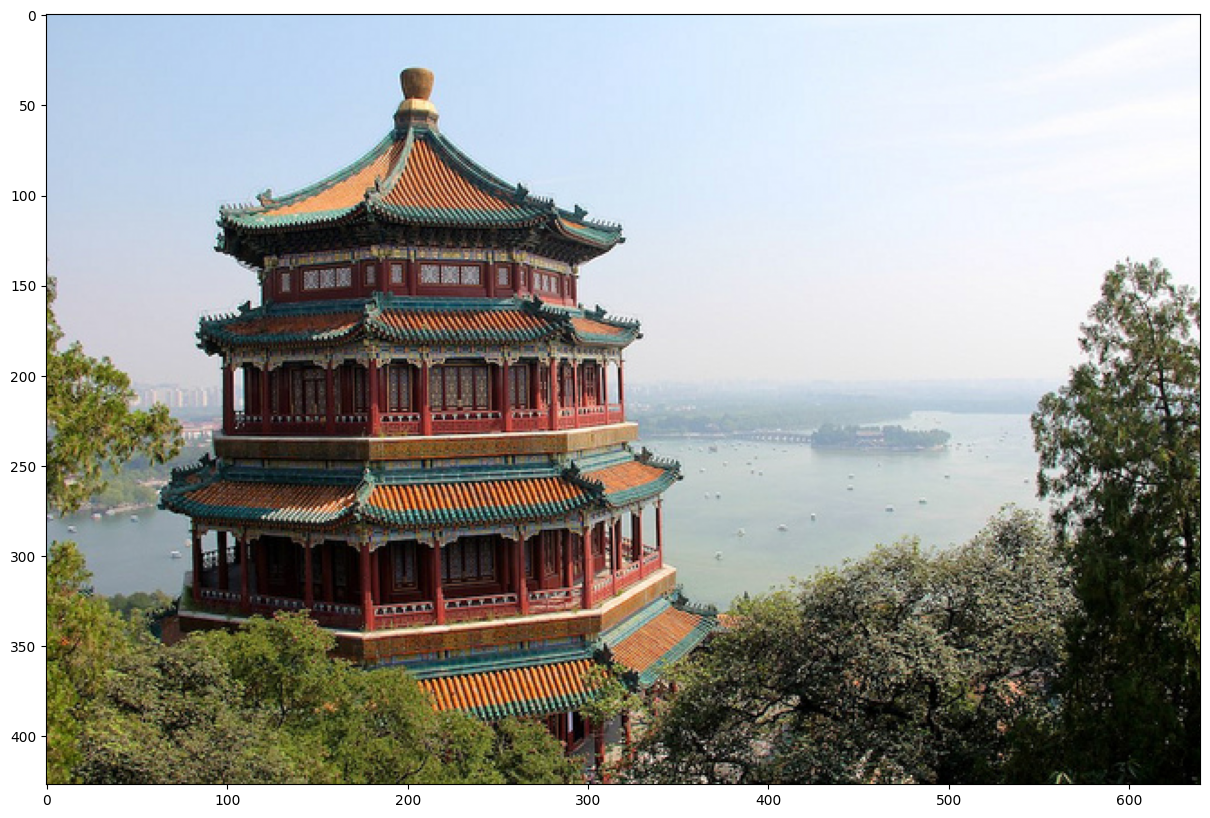

In [12]:
plt.figure(figsize=(20,10))
_ = plt.imshow(china)

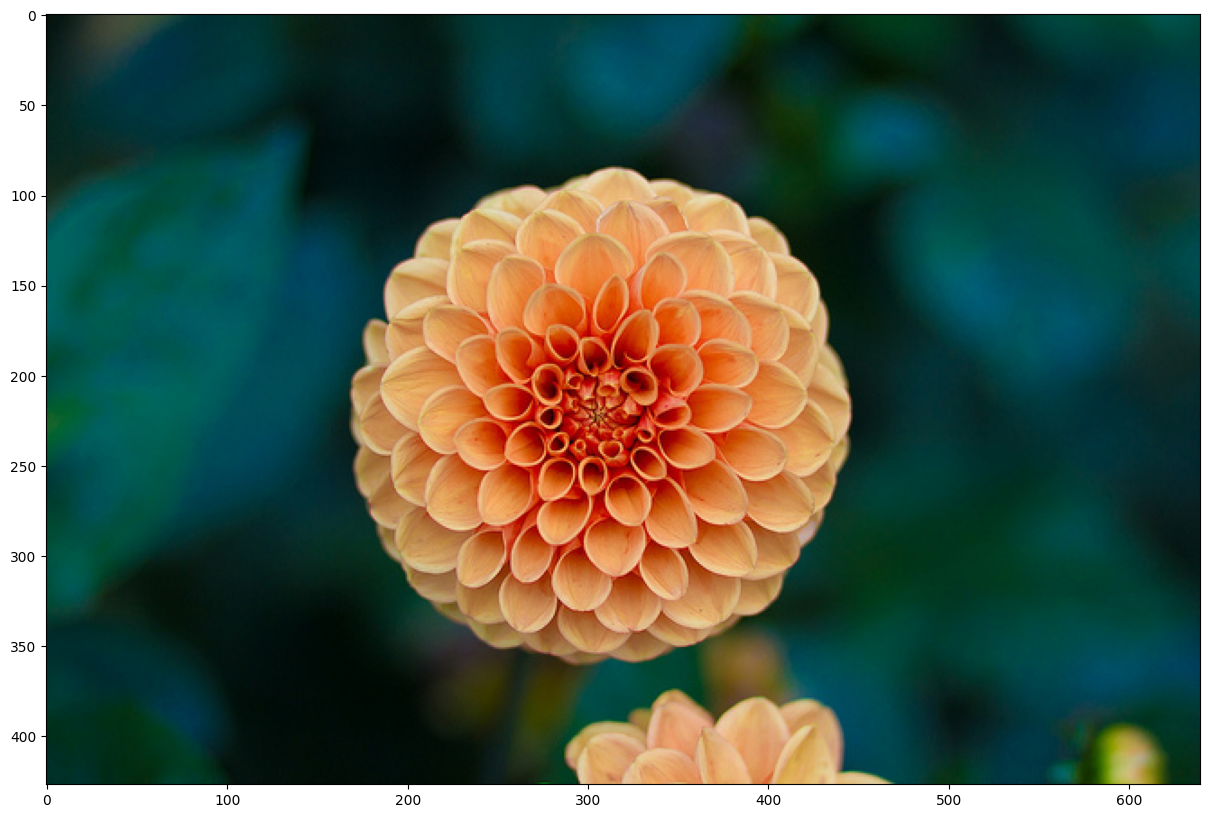

In [13]:
plt.figure(figsize=(20,10))
_ = plt.imshow(flower)

#### Creamos los filtros

In [14]:
batch_size, height, width, channels = images.shape
# Create a vertical and a horizontal filter.
filters_line = np.zeros(shape=(7, 7, channels, 2), dtype=np.float32)
filters_line[:, 3, :, 0] = 1 # vertical line
filters_line[3, :, :, 1] = 1 # horizontal line
print("Vertical filter (line)\n", filters_line[:,:,1,0])
print("Filter (line) Horizontal\n", filters_line[:,:,1,1])

Vertical filter (line)
 [[0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]]
Filter (line) Horizontal
 [[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]


Create a vertical and a horizontal filter of dimension 3x3 like the ones seen in class.

In [15]:
# TODO
filters = np.zeros(shape=(3,3,channels,2), dtype=np.float32)
filters[0,:,:,0] = 1
filters[2,:,:,0] = -1
filters[:,0,:,1] = 1
filters[:,2,:,1] = -1

print("Horizontal filter\n", filters[:,:,1,0])
print("Vertical filter\n", filters[:,:,1,1])

Horizontal filter
 [[ 1.  1.  1.]
 [ 0.  0.  0.]
 [-1. -1. -1.]]
Vertical filter
 [[ 1.  0. -1.]
 [ 1.  0. -1.]
 [ 1.  0. -1.]]


In [16]:
#SOLUTION
filters = np.zeros(shape=(3, 3, channels, 2), dtype=np.float32)
filters[0, :, :, 0] = 1 # horizontal filter
filters[2, :, :, 0] = -1 # horizontal filter

filters[:, 0, :, 1] = 1 # vertical filter
filters[:, 2, :, 1] = -1 # vertical filter
print("Horizontal filter\n", filters[:,:,1,0])
print("Vertical filter\n", filters[:,:,1,1])

Horizontal filter
 [[ 1.  1.  1.]
 [ 0.  0.  0.]
 [-1. -1. -1.]]
Vertical filter
 [[ 1.  0. -1.]
 [ 1.  0. -1.]
 [ 1.  0. -1.]]


#### Perform a convolution with the filters.
Use `tf.nn.conv2d` to apply the created filters to the images.
The size of the resulting image has to be the same as the size of the input images.

In [17]:
print(images.shape)
outputs = tf.nn.conv2d(images,filters,1,"SAME")
print(outputs.shape)

(2, 427, 640, 3)
(2, 427, 640, 2)


In [18]:
#SOLUTION
print(images.shape)
outputs = tf.nn.conv2d(images, filters, strides=1, padding="SAME")
print(outputs.shape)

(2, 427, 640, 3)
(2, 427, 640, 2)


How many channels do the images have before and after applying the filters?

SOLUTION: 3 input channels, 2 output channels

#### Horizontal filter

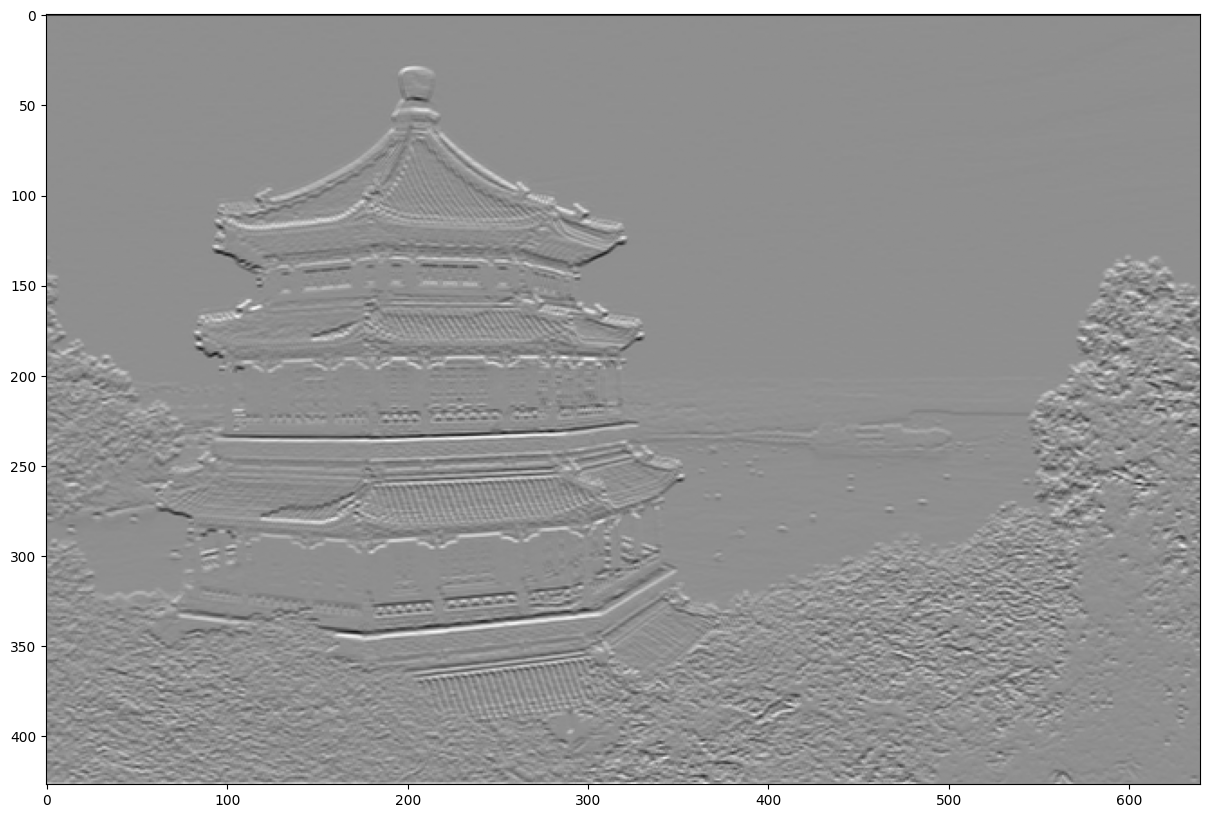

In [19]:
# outputs[0, :, :, 0] China
# outputs[1, :, :, 0] Flower
# outputs[0, :, :, 1] Vertical
# outputs[0, :, :, 0] Horizontal
plt.figure(figsize=(20,10))
_ = plt.imshow(outputs[0, :, :, 0], cmap="gray") #

#### Vertical filter

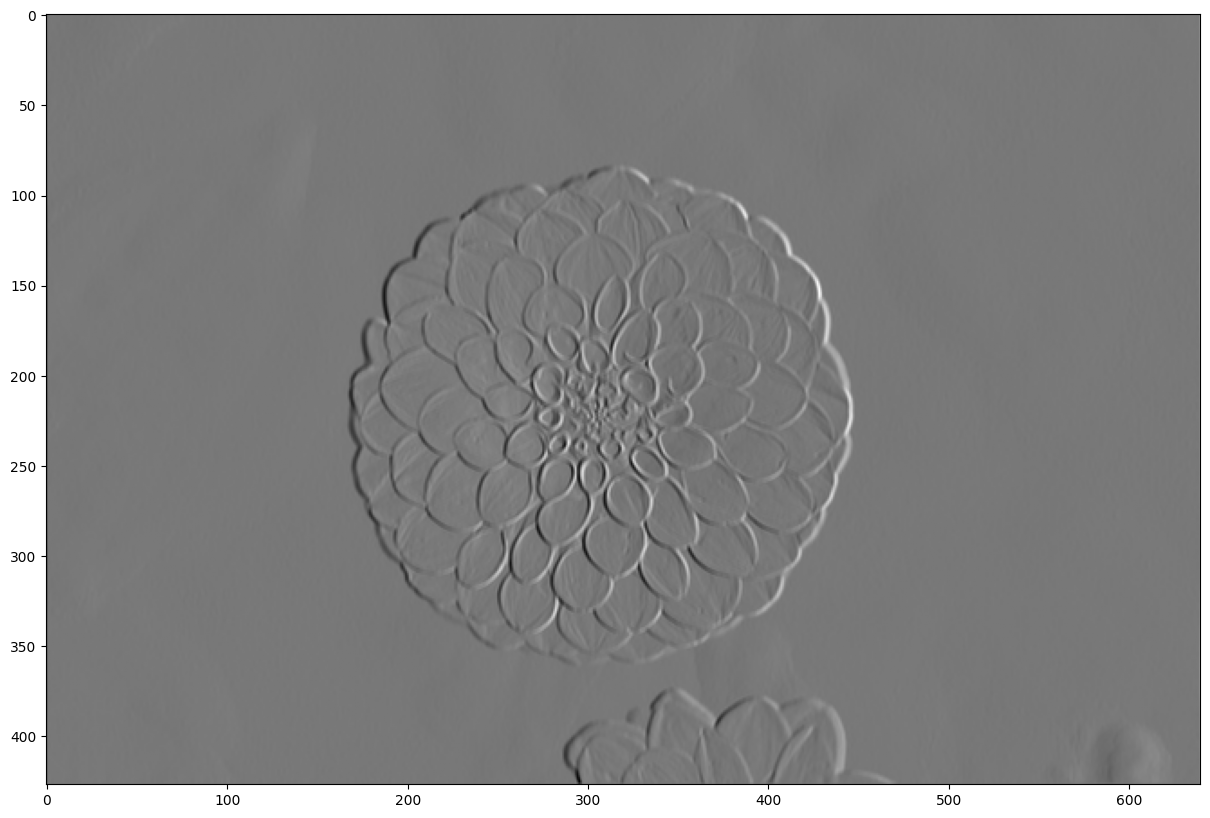

In [20]:
# outputs[0, :, :, 0] China
# outputs[1, :, :, 0] Flower
# outputs[0, :, :, 1] Vertical
# outputs[0, :, :, 0] Horizontal
plt.figure(figsize=(20,10))
_ = plt.imshow(outputs[1, :, :, 1], cmap="gray")

## Pooling

#### Max Pooling with $f=3, s=3$ for height and width
The result is a lower resolution image with the most important features. You can see that the edges are more distinct.

Use `tf.nn.max_pool` to apply max spatial pooling (width and height) with valid padding.

Kernel Size and strides expect a tuple with size/stride `( between instances, height, width, channels)`.

In [21]:
output = tf.nn.max_pool(outputs, ksize=(1, 3, 3, 1), strides=(1, 3, 3, 1), padding="VALID")

In [ ]:
# SOLUTION
#To the original image
#output = tf.nn.max_pool(images, ksize=(1, 3, 3, 1), strides=(1, 3, 3, 1), padding="VALID")
#To the result of the convolution
output = tf.nn.max_pool(outputs, ksize=(1, 3, 3, 1), strides=(1, 3, 3, 1), padding="VALID")
#Repeat operation to further enhance the results.
#output = tf.nn.max_pool(output, ksize=(1, 3, 3, 1), strides=(1, 3, 3, 1), padding="VALID")

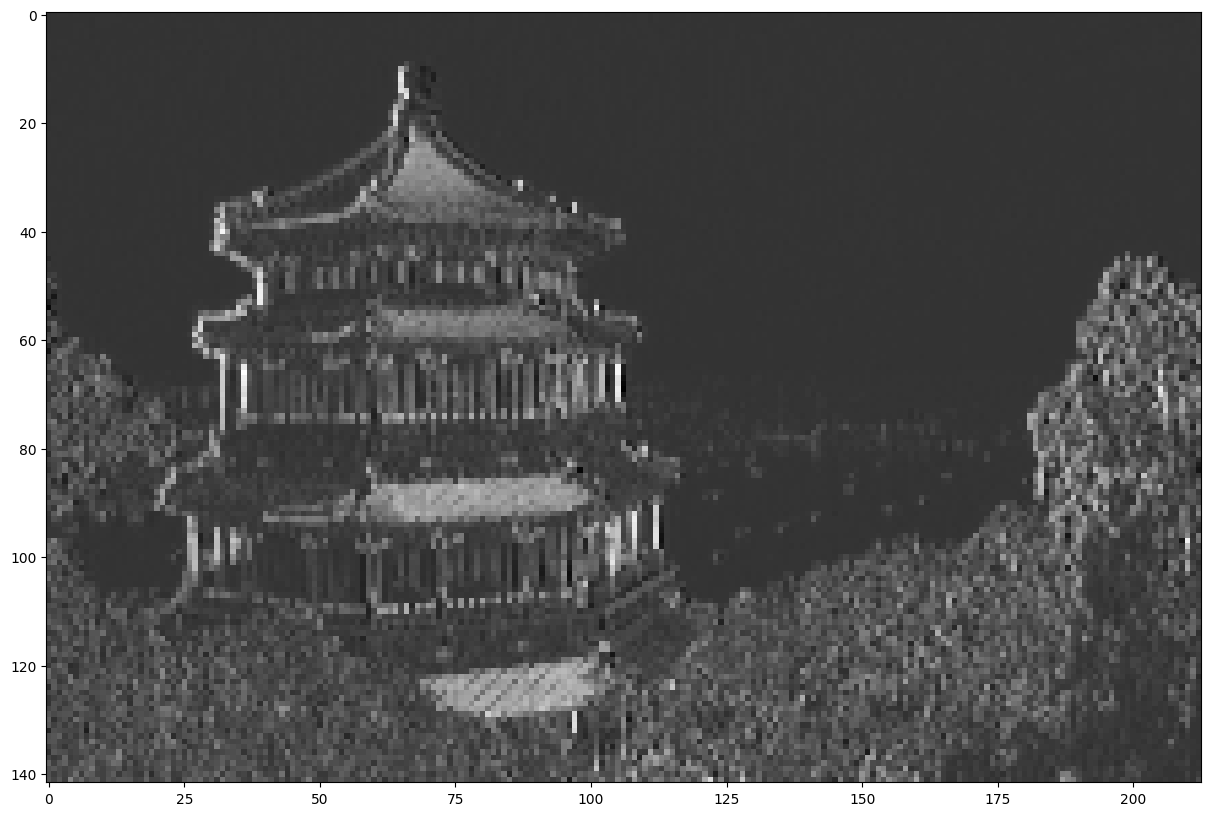

In [14]:
# outputs[0, :, :, 0] China
# outputs[1, :, :, 0] Flower
# outputs[0, :, :, 1] Vertical
# outputs[0, :, :, 0] Horizontal
plt.figure(figsize=(20,10))
_ = plt.imshow(output[0, :, :, 1], cmap="gray")

#### Avg Pooling with $f=3, s=3$ for height and width
The result is a lower resolution image that looks more like the original. However some details may disappear more easily. Where are the boats?

Use tf.nn.avg_pool to apply spatial avg pooling (width and height) with valid padding.

In [15]:
output = tf.nn.avg_pool(outputs, ksize=(1, 3, 3, 1), strides=(1, 3, 3, 1), padding="VALID")

In [ ]:
# SOLUTION
#To the original image
#output = tf.nn.avg_pool(images, ksize=(1, 3, 3, 1), strides=(1, 3, 3, 1), padding="VALID")
#To the result of the convolution
output = tf.nn.avg_pool(outputs, ksize=(1, 3, 3, 1), strides=(1, 3, 3, 1), padding="VALID")
#Repeat operation to further enhance the results.
#output = tf.nn.avg_pool(output, ksize=(1, 3, 3, 1), strides=(1, 3, 3, 1), padding="VALID")

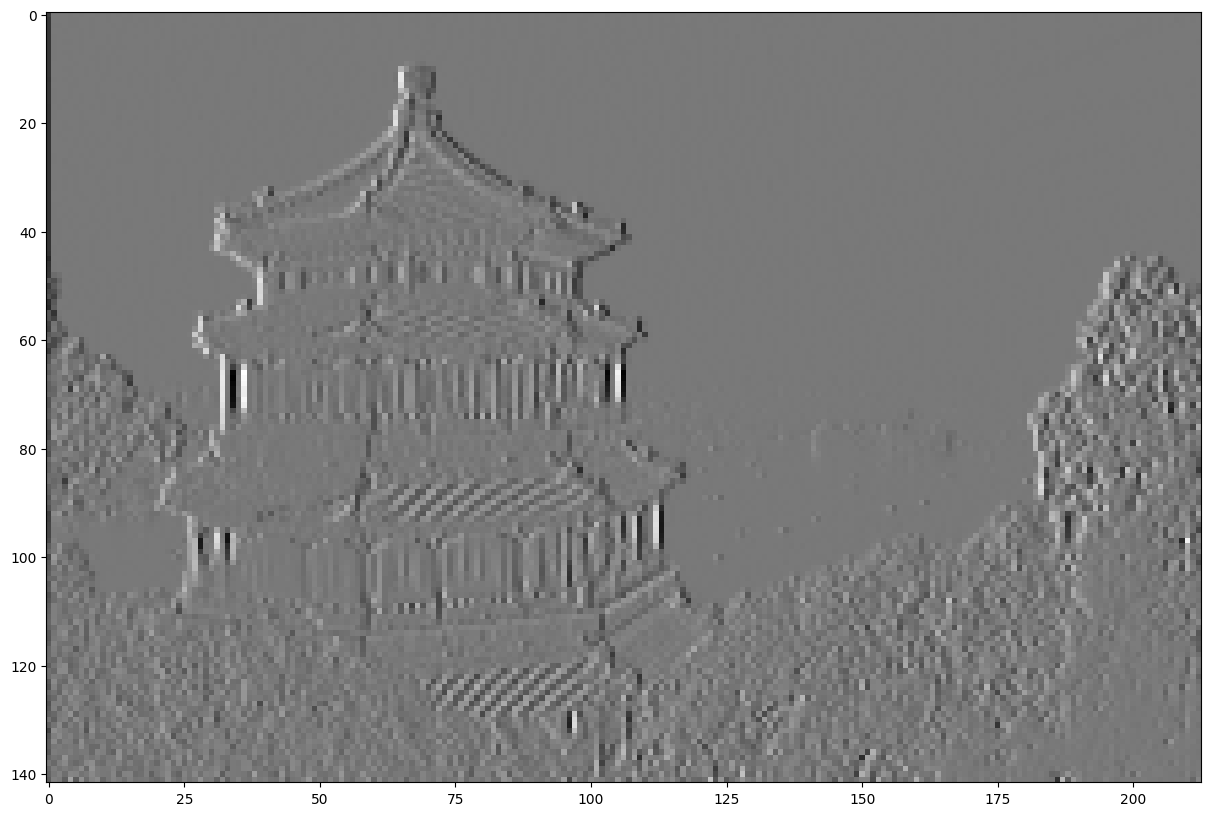

In [16]:
# outputs[0, :, :, 0] China
# outputs[1, :, :, 0] Flower
# outputs[0, :, :, 0] Vertical
# outputs[0, :, :, 0] Horizontal
plt.figure(figsize=(20,10))
_ = plt.imshow(output[0, :, :, 1], cmap="gray")

#### Max Pooling with $f=2, s=2$ for the channels
The result is a grayscale image. By using a max pooling type, again the most important features are enhanced.

If we apply it on the results of the vertical and horizontal filters, we will have a combination of both vertical and horizontal highlighted edges.

Use tf.nn.max_pool to apply max pooling in depth (channels) with a valid padding.

In [ ]:
output = tf.nn.max_pool(outputs, ksize=(1, 1, 1, 2), strides=(1, 1, 1, 2), padding="VALID")

In [ ]:
# SOLUTION
output = tf.nn.max_pool(outputs, ksize=(1, 1, 1, 2), strides=(1, 1, 1, 2), padding="VALID")

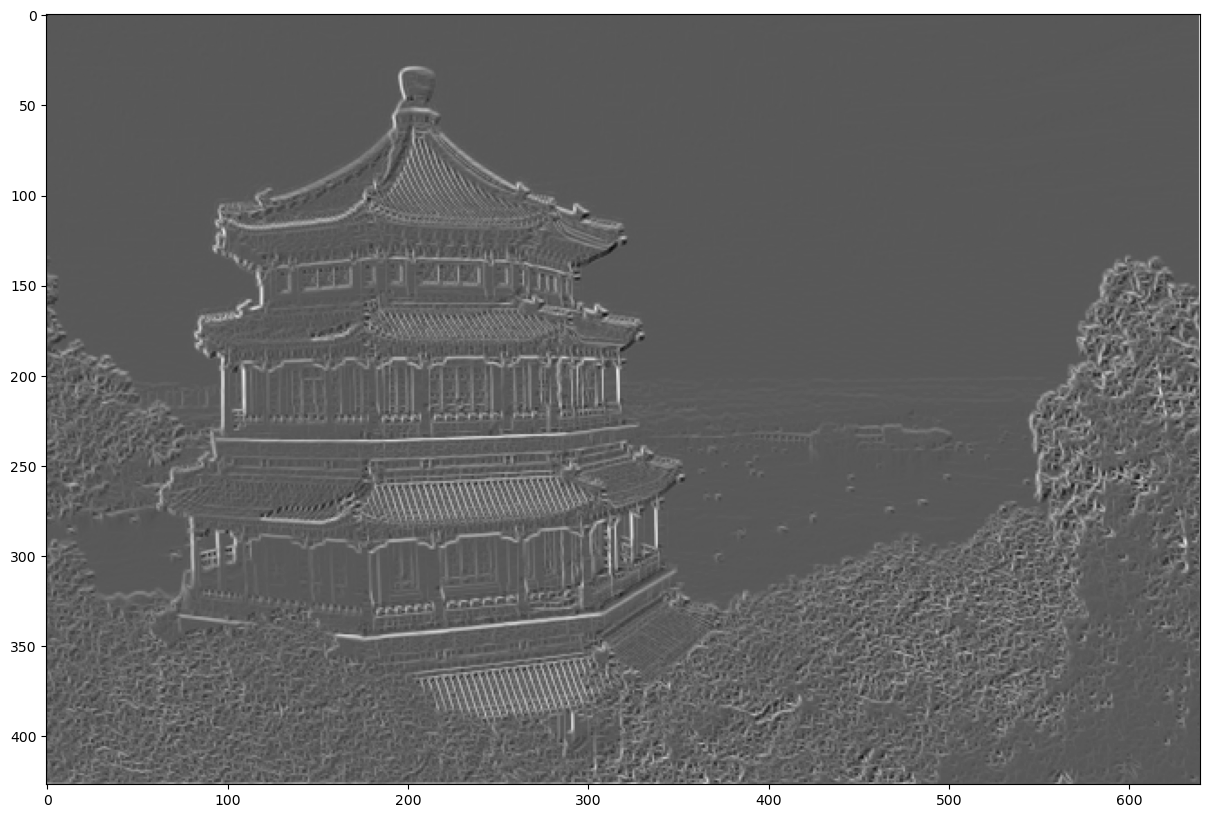

In [ ]:
plt.figure(figsize=(20,10))
_ = plt.imshow(output[0, :, :, 0], cmap="gray")

#### Avg Pooling con $f=2, s=2$ para los canales
Ops, aún no está implementado. ¿Algún voluntario?

## My first CNN: Fashion Mnist
It can achieve about an accuracy of $0.92$

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


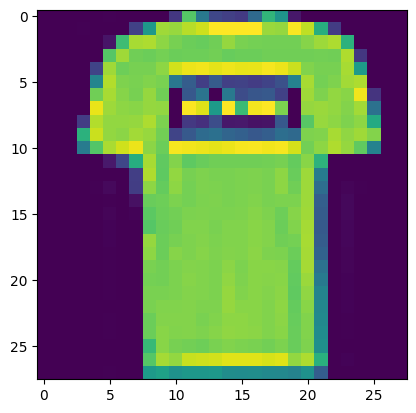

In [3]:
from tensorflow.keras.datasets import fashion_mnist
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.reshape((X_train.shape[0], 28, 28,1))/255.
X_test = X_test.reshape((X_test.shape[0], 28, 28,1))/255.


# If you use the output of the dataset as it is (indexes)
# use with sparse_categorical_cross_entropy

# use categorical_cross_entropy with
#y_train = keras.utils.to_categorical(y_train, num_classes=10)
#y_test = keras.utils.to_categorical(y_test, num_classes=10)

_ = plt.imshow(X_train[1,:,:,0])

### Create a CNN using samme padding with:
* 1 layer with 64 filters of dimension 7 and max pool of dimension 2
* 1 layer with convolution of 128 filters of dimension 3 and max pool of dimension 2
* 1 layer with convolution of 256 filters of dimension 3 and max pool of dimension 2
* 1 layer of Dense type of dimension 128
* Dropout at 0.5
* 1 layer of Dense type with dimension 64
* Dropout at 0.5
* 1 layer of Dense type of dimension 10

Use GPU or TPU (Colab)

In [6]:
#TODO
model = keras.models.Sequential([
    Conv2D(filters=64,kernel_size=7,activation="relu",input_shape=[28,28,1]),
    MaxPooling2D(pool_size=2),
    Conv2D(filters=128,kernel_size=3,activation="relu",padding="same"),
    MaxPooling2D(pool_size=2),
    Conv2D(filters=256,kernel_size=3,activation="relu",padding="same"),
    MaxPooling2D(pool_size=2),
    Flatten(),
    Dense(units=128,activation="relu"),
    Dropout(0.5),
    Dense(units=64,activation="relu"),
    Dropout(0.5),
    Dense(units=10,activation="softmax")
])

model.summary()

model.compile(optimizer='nadam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
              )

history = model.fit(X_train, y_train, validation_split = 0.2, epochs=7)
print('CNN básica: ', model.evaluate(X_test, y_test))

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 22, 22, 64)     │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 5, 5, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 512,330 (1.95 MB)

 Trainable params: 512,330 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.6094 - loss: 1.0900 - val_accuracy: 0.8508 - val_loss: 0.4124
Epoch 2/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8403 - loss: 0.4718 - val_accuracy: 0.8655 - val_loss: 0.3662
Epoch 3/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8637 - loss: 0.4024 - val_accuracy: 0.8853 - val_loss: 0.3116
Epoch 4/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8810 - loss: 0.3508 - val_accuracy: 0.8898 - val_loss: 0.2986
Epoch 5/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8929 - loss: 0.3140 - val_accuracy: 0.8894 - val_loss: 0.2962
Epoch 6/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8983 - loss: 0.2941 - val_accuracy: 0.8977 - val_loss: 0.2776
Epoch 7/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9026 - loss: 0.2798 - val_accuracy: 0.8988 - val_loss: 0.2831
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8881 - loss: 0.3212
CNN básica:  [0.3067

### ResNet

Let's avoid burning out the computer by training models to classify images.

[Keras](https://keras.io/applications/) provides models of some of the most famous convolutional networks trained to recognize images from [Image Net](http://www.image-net.org/).

This simplifies the training when we have the possibility to do **transfer learning**.

Let's load a ResNet

In [7]:
model = keras.applications.resnet50.ResNet50(weights="imagenet")

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Let's try to recognize what the images are using the loaded model.

In [22]:
images_resized = tf.image.resize(images, [224, 224])
inputs = keras.applications.resnet50.preprocess_input(images_resized * 255)
Y_proba = model.predict(inputs)
top_K = keras.applications.resnet50.decode_predictions(Y_proba, top=3)
for image_index in range(len(images)):
    print("Image #{}".format(image_index))
    for class_id, name, y_proba in top_K[image_index]:
        print(" {} - {:12s} {:.2f}%".format(class_id, name, y_proba * 100))
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Image #0
 n02825657 - bell_cote    82.35%
 n03877845 - palace       6.75%
 n03781244 - monastery    4.19%

Image #1
 n03530642 - honeycomb    49.81%
 n13040303 - stinkhorn    33.96%
 n02206856 - bee          4.35%



#### Let's try an image of us

In [24]:
# example of loading an image with the Keras API
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
# load the image
img = img_to_array(load_img('beer.jpg'))
img = tf.image.resize(img, [224, 224])
_ = plt.imshow(tf.dtypes.cast(img, tf.int32))

FileNotFoundError: [Errno 2] No such file or directory: 'beer.jpg'

Obtain the top 3 most probable classifications for our image

In [ ]:
#TODO

In [ ]:
#SOLUTION
inputs = keras.applications.resnet50.preprocess_input(tf.reshape(img, (1,224,224,3)))
Y_proba = model.predict(inputs)
top_K = keras.applications.resnet50.decode_predictions(Y_proba, top=3)
for class_id, name, y_proba in top_K[0]:
    print(" {} - {:12s} {:.2f}%".format(class_id, name, y_proba * 100))


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
 n02823428 - beer_bottle  84.47%
 n03937543 - pill_bottle  4.83%
 n04591713 - wine_bottle  4.26%


### Transfer Learning
First let's import a dataset for flower recognition.

In [25]:
import tensorflow_datasets as tfds

_, info = tfds.load("tf_flowers", with_info=True)
class_names = info.features["label"].names
dataset_size = info.splits["train"].num_examples
n_classes = info.features["label"].num_classes
test_set_raw, valid_set_raw, train_set_raw = tfds.load(
    "tf_flowers",
    split=["train[:10%]", "train[10%:25%]", "train[25%:]"],
    as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.SLX0K3_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [ ]:
plt.figure(figsize=(12, 10))
index = 0
for image, label in train_set_raw.take(9):
    index += 1
    plt.subplot(3, 3, index)
    plt.imshow(image)
    plt.title("Class: {}".format(class_names[label]))
    plt.axis("off")

Then we would perform the preprocessing of the images and take the opportunity to perform some transformations (data augmentation).

In [ ]:
from functools import partial

def central_crop(image):
    shape = tf.shape(image)
    min_dim = tf.reduce_min([shape[0], shape[1]])
    top_crop = (shape[0] - min_dim) // 4
    bottom_crop = shape[0] - top_crop
    left_crop = (shape[1] - min_dim) // 4
    right_crop = shape[1] - left_crop
    return image[top_crop:bottom_crop, left_crop:right_crop]

def random_crop(image):
    shape = tf.shape(image)
    min_dim = tf.reduce_min([shape[0], shape[1]]) * 90 // 100
    return tf.image.random_crop(image, [min_dim, min_dim, 3])

def preprocess(image, label, randomize=False):
    if randomize:
        cropped_image = random_crop(image)
        cropped_image = tf.image.random_flip_left_right(cropped_image)
    else:
        cropped_image = central_crop(image)
    resized_image = tf.image.resize(cropped_image, [224, 224])
    final_image = keras.applications.xception.preprocess_input(resized_image)
    return final_image, label

batch_size = 32
train_set = train_set_raw.shuffle(1000).repeat()
train_set = train_set.map(partial(preprocess, randomize=True)).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(preprocess).batch(batch_size).prefetch(1)
test_set = test_set_raw.map(preprocess).batch(batch_size).prefetch(1)

Let's import the model and change the last layers to make transfer learning to our problem

In [ ]:
#Import base model (Xception) without classification layers (include_top=False)
base_model = #TODO
# Add our layers for classification
# Apply Global Average Pooling
avg = #TODO
# Create output layer for classification with n_classes mutually exclusive
# We can include any additional layer if necessary.
output = #TODO
#Define the model
model = #TODO

In [ ]:
#SOLUTION
#Import base model (Xception) without classification layers (include_top=False)
base_model = keras.applications.xception.Xception(weights="imagenet", include_top=False)
# Add our layers for classification
# Apply Global Average Pooling
avg = keras.layers.GlobalAveragePooling2D()(base_model.output)
# Create output layer for classification with n_classes mutually exclusive
# We can include any additional layer if necessary.
output = keras.layers.Dense(n_classes, activation="softmax")(avg)
#Define the model
model = keras.Model(inputs=base_model.input, outputs=output)

Let's prepare and train the model

In [ ]:
# We freeze the weights of the base model to get the most out of the pre-trained model.
#TODO

#Let's start with a slightly more aggressive learning constant.
optimizer = keras.optimizers.SGD(learning_rate=0.2, momentum=0.9)
model.compile(#TODO)
# For very large datasets it is convenient to define the number of steps per epoch (steps_per_epoch).
history = model.fit(train_set,
                    #We use only 75% of the data in each period to speed up the training.
                    steps_per_epoch=int(0.75 * dataset_size / batch_size),
                    validation_data=valid_set,
                    validation_steps=int(0.15 * dataset_size / batch_size),
                    epochs=5)

In [ ]:
#SOLUTION
# We freeze the weights of the base model to get the most out of the pre-trained model.
base_model.trainable = False

#Let's start with a slightly more aggressive learning constant.
optimizer = keras.optimizers.SGD(learning_rate=0.2, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
# For very large datasets it is convenient to define the number of steps per epoch (steps_per_epoch).
history = model.fit(train_set,
                    #We use only 75% of the data in each period to speed up the training.
                    steps_per_epoch=int(0.75 * dataset_size / batch_size),
                    validation_data=valid_set,
                    validation_steps=int(0.15 * dataset_size / batch_size),
                    epochs=5)
model.evaluate(test_set)

Most often, the training is stuck at an unsatisfactory level of accuracy. If this happens, we continue the training by including the weights of the pre-trained model and applying a lower learning constande.

Apply:
* learning constant: $0.001$.
* decay of the learning constant $0.0001$.

In [ ]:
#TODO

In [ ]:
#SOLUTION
base_model.trainable = True

optimizer = keras.optimizers.SGD(lerning_rate=0.001, momentum=0.9, decay=0.0001)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
history = model.fit(train_set,
                    #We use only 75% of the data in each period to speed up the training.
                    steps_per_epoch=int(0.75 * dataset_size / batch_size),
                    validation_data=valid_set,
                    validation_steps=int(0.15 * dataset_size / batch_size),
                    epochs=5)
model.evaluate(test_set)